Stuart Rossiter, C00284845

# Licensing
Fuzzy C-Means clustering on the SKLearn Iris dataset Copyright (C) 2025 Stuart Rossiter

This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.

You should have received a copy of the GNU General Public License along with this program. If not, see https://www.gnu.org/licenses/.

# Fuzzy C-Means clustering - Iris clustering
Using Fuzzy C-means, we'll be performing analysis on SKLearn's built-in Iris dataset. It The Iris dataset has a well-known fuzzy zone between versicolor and virginica - making it ideal for FCM. 

# Preprocessing
First things first, let's import the data, and drop the unnecessary columns.

In [1]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
#0=setosa, 1=versicolor, 2=virginica
y_true = iris.target
feature_names = iris.feature_names
target_names  = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y_true]

With our data imported, we must scale it.

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
data = X_scaled.T

Now that our data is imported, we can create and train our model. We'll use skfuzzy for this, as SKLearn doesn't have a fuzzy c-means model.

In [7]:
import skfuzzy as fuzz

cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
    data, 
    c=3, 
    m=2,
    error=0.005, 
    maxiter=1000, 
    init=None
)

print('FPC (c=3): ' + str(fpc) + ' (1.0 = hard, 1/c ≈ 0.33 = fully fuzzy)')

FPC (c=3): 0.7064996319805058 (1.0 = hard, 1/c ≈ 0.33 = fully fuzzy)


The FPC, or the Fuzzy Partition Coefficient, shows us how much overlap there was between the clusters. a high number like 0.9 shows harder borders between clusters, where a number equal to 1 / cluster count shows a fully fuzzy model. Lets plot the model and see what happens.

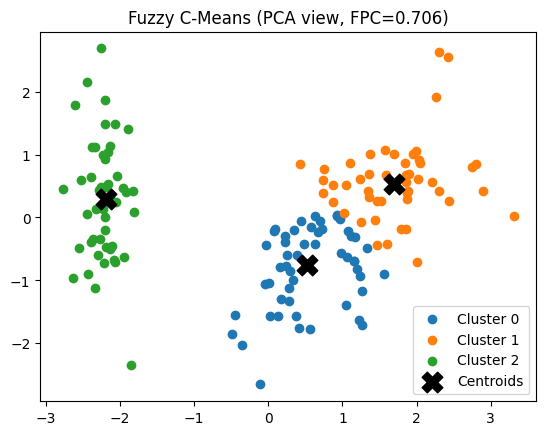

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

cntr_pca = pca.transform(cntr)

plt.figure()

for i in range(3):
    plt.scatter( X_2d[labels == i, 0], X_2d[labels == i, 1], label=f'Cluster {i}')
plt.scatter(cntr_pca[:, 0], cntr_pca[:, 1], s=220, c='black',marker='X', zorder=6, label='Centroids')
plt.title(f'Fuzzy C-Means (PCA view, FPC={fpc:.3f})')
plt.legend()
plt.show()

We can see 3 distinct clusters. This aligns well with the used dataset, which has the 3 categories of Setosa, Versicolor, and Virginica. 2 of the clusters are noticably less distinct, however. The groups of Cluster 0 and Cluster 1 are harder to distinguish, as there is a level of overlap to them. This is expected, as Versicolor and Virginica have a known fuzzy zone between them.

# Conclusion
Using Fuzzy C-Means, we could identify 3 clusters which closely align with the existing categories of Iris'. We identified the Fuzzy Zone between clusters 0 and 1, which matches the expected Fuzzy Zone between Versicolor and Virginica. The model is well tailored to this kind of data.